In [2]:
library(tidyverse)
library(stringr)
library(readr)
library(fs)
library(ggplot2)
library(dplyr)
library(broom)
library(tidyr)

In [3]:
if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, stringr, readxl, data.table, gdata, scales, kableExtra, modelsummary)

f <- function(x) {
  r <- quantile(x, probs = c(0.10, 0.25, 0.5, 0.75, 0.90))
  names(r) <- c("ymin","lower","middle","upper","ymax")
  r
}

Loading required package: pacman

Installing package into ‘/home/ski2983/R/x86_64-conda-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)

Warning message in utils::install.packages(package, ...):
“installation of package ‘kableExtra’ had non-zero exit status”

kableExtra installed

Installing package into ‘/home/ski2983/R/x86_64-conda-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bayestestR’, ‘datawizard’, ‘data.table’, ‘insight’, ‘parameters’, ‘performance’, ‘tables’, ‘tinytable’


Warning message in utils::install.packages(package, ...):
“installation of package ‘insight’ had non-zero exit status”
Warning message in utils::install.packages(package, ...):
“installation of package ‘tables’ had non-zero exit status”
Warning message in utils::install.packages(package, ...):
“installation of package ‘datawizard’ had non-zero exit status”
Warning message in utils::install.packages(package, ...):
“installation of package ‘bayestestR’ had non-zero exit s

In [4]:
data.2010 <- read_csv("..//data/data-2010.csv")
data.2011 <- read_csv("..//data/data-2011.csv")
data.2012 <- read_csv("..//data/data-2012.csv")
data.2013 <- read_csv("..//data/data-2013.csv")
data.2014 <- read_csv("..//data/data-2014.csv")
data.2015 <- read_csv("..//data/data-2015.csv")

Rows: 108222 Columns: 91
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (15): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (66): planid, fips, n_nonmiss, avg_enrollment, sd_enrollment, min_enroll...
lgl (10): partcd_score, risk_star5, risk_star45, risk_star4, risk_star35, ri...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 68003 Columns: 95
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (15): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (71): planid, fips, n_nonmiss, avg_enrollment, sd_enrollment, min_enroll...
lgl  (9): risk_star5, risk_star45, risk_star4, risk_star35, risk_star3, risk...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types =

In [5]:
fix_type <- function(df) {
  df$org_parent <- as.character(df$org_parent)
  df
}

data.2011 <- fix_type(data.2011)

In [6]:
combined <- bind_rows(
  data.2010,
  data.2011,
  data.2012,
  data.2013,
  data.2014,
  data.2015
) %>%
  mutate(mkt_share = avg_enrollment / avg_enrolled)

In [7]:
colnames(combined)

[1] "contractid"          "planid"              "fips"               
  [4] "n_nonmiss"           "avg_enrollment"      "sd_enrollment"      
  [7] "min_enrollment"      "max_enrollment"      "first_enrollment"   
 [10] "last_enrollment"     "state"               "county"             
 [13] "org_type"            "plan_type"           "partd"              
 [16] "snp"                 "eghp"                "org_name"           
 [19] "org_marketing_name"  "plan_name"           "parent_org"         
 [22] "contract_date"       "state_long"          "county_long"        
 [25] "n_elig"              "n_enrol"             "avg_eligibles"      
 [28] "sd_eligibles"        "min_eligibles"       "max_eligibles"      
 [31] "first_eligibles"     "last_eligibles"      "avg_enrolled"       
 [34] "sd_enrolled"         "min_enrolled"        "max_enrolled"       
 [37] "first_enrolled"      "last_enrolled"       "ssa"                
 [40] "ncount"              "breastcancer_screen" "rectalcancer_screen"
 [43] "cv_diab_cholscreen"  "glaucoma_test"       "monitoring"         
 [46] "flu_vaccine"         "pn_vaccine"          "physical_health"    
 [49] "mental_health"       "osteo_test"          "physical_monitor"   
 [52] "primaryaccess"       "osteo_manage"        "diab_healthy"       
 [55] "bloodpressure"       "ra_manage"           "copd_test"          
 [58] "bladder"             "falling"             "nodelays"           
 [61] "doctor_communicate"  "carequickly"         "customer_service"   
 [64] "overallrating_care"  "overallrating_plan"  "complaints_plan"    
 [67] "appeals_timely"      "appeals_review"      "leave_plan"         
 [70] "audit_problems"      "hold_times"          "info_accuracy"      
 [73] "ttyt_available"      "new_contract"        "partc_score"        
 [76] "partcd_score"        "Star_Rating"         "aged_parta"         
 [79] "aged_partb"          "risk_ab"             "risk_star5"         
 [82] "risk_star45"         "risk_star4"          "risk_star35"        
 [85] "risk_star3"          "risk_star25"         "risk_bonus5"        
 [88] "risk_bonus35"        "risk_bonus0"         "year"               
 [91] "ma_rate"             "org_parent"          "cv_cholscreen"      
 [94] "diab_cholscreen"     "bmi_assess"          "specialneeds_manage"
 [97] "older_medication"    "older_function"      "older_pain"         
[100] "diabetes_eye"        "diabetes_kidney"     "diabetes_bloodsugar"
[103] "diabetes_chol"       "readmissions"        "coordination"       
[106] "improve"             "X39"                 "X40"                
[109] "low_score"           "X41"                 "X42"                
[112] "access_problems"     "mkt_share"

# Problem 1

In [8]:
summary_table <- combined %>%
  group_by(year) %>%
  summarise(
    `Mean Star Rating` = round(mean(Star_Rating, na.rm = TRUE), 2),
    `Mean Enrollments` = round(mean(avg_enrollment, na.rm = TRUE), 2),
    `Mean Market Share` = round(mean(mkt_share, na.rm = TRUE), 4),
    `Total Plans` = n()
  )

print(summary_table)

# A tibble: 6 × 5
   year `Mean Star Rating` `Mean Enrollments` `Mean Market Share` `Total Plans`
  <dbl>              <dbl>              <dbl>               <dbl>         <int>
1  2010               2.97               256.              0.0658        108222
2  2011               3.26               343.              0.0855         68003
3  2012               3.36               377.              0.0856         67246
4  2013               3.55               396.              0.0815         67835
5  2014               3.81               437.              0.08           62344
6  2015               3.96               470.              0.0787         65499


# Problem 2

In [9]:
summary_no_rating <- combined %>%
  filter(is.na(Star_Rating)) %>%
  group_by(year) %>%
  summarise(
    `Mean Enrollments` = round(mean(avg_enrollment, na.rm = TRUE), 2),
    `Mean Market Share` = round(mean(mkt_share, na.rm = TRUE), 4),
    `Total Plans` = n()
  )

print(summary_no_rating)

# A tibble: 6 × 4
   year `Mean Enrollments` `Mean Market Share` `Total Plans`
  <dbl>              <dbl>               <dbl>         <int>
1  2010               107.              0.0673         48643
2  2011               168.              0.09           12754
3  2012               173.              0.0567          9077
4  2013               214.              0.06            3661
5  2014               258.              0.0557          3708
6  2015               314.              0.0405          4680


# Problem 3

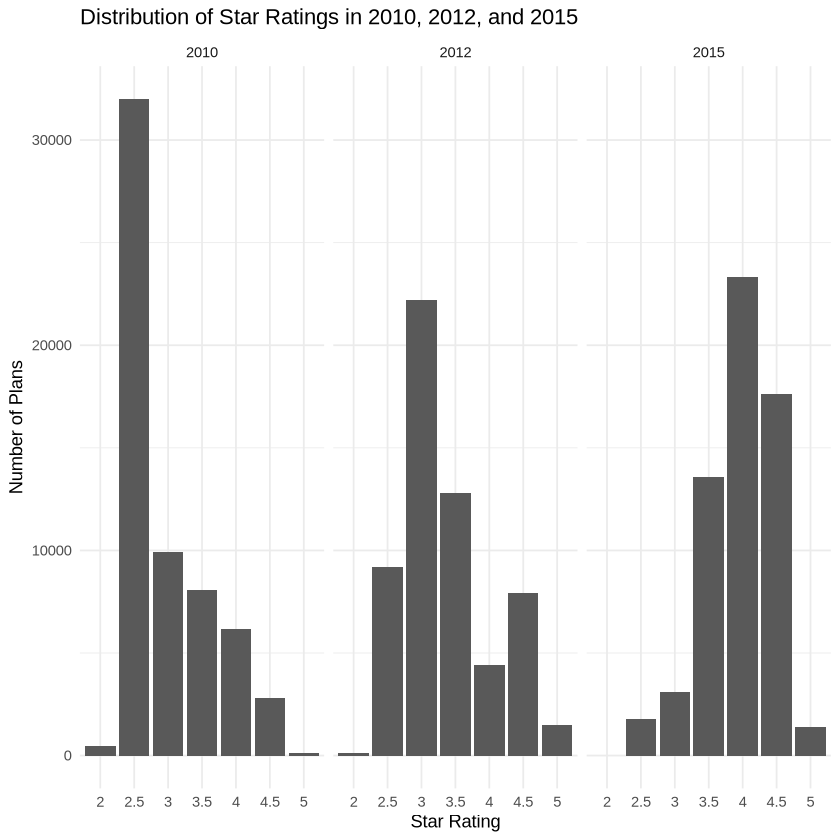

In [10]:
combined %>%
  filter(year %in% c(2010, 2012, 2015), !is.na(Star_Rating)) %>%
  mutate(year = as.factor(year)) %>%
  ggplot(aes(x = as.factor(Star_Rating))) +
  geom_bar() +
  facet_wrap(~ year) +
  labs(
    title = "Distribution of Star Ratings in 2010, 2012, and 2015",
    x = "Star Rating",
    y = "Number of Plans"
  ) +
  theme_minimal()

# Problem 4

In [28]:
combined <- combined %>%
  mutate(
    star_3   = as.integer(partc_score == 3),
    star_35  = as.integer(partc_score== 3.5),
    star_4   = as.integer(partc_score == 4),
    star_45  = as.integer(partc_score >= 4.5)
  )

results_list <- list()

for(yr in 2010:2015){
  cat("\nYear:", yr, "\n")
  ols <- lm(mkt_share ~ star_3 + star_35 + star_4 + star_45, 
            data = combined %>% filter(year == yr, !is.na(partc_score), !is.na(mkt_share)))
  print(summary(ols))
}



Year: 2010 

Call:
lm(formula = mkt_share ~ star_3 + star_35 + star_4 + star_45, 
    data = combined %>% filter(year == yr, !is.na(partc_score), 
        !is.na(mkt_share)))

Residuals:
     Min       1Q   Median       3Q      Max 
-0.07593 -0.05415 -0.03449  0.01530  0.72831 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.0633531  0.0009855  64.288  < 2e-16 ***
star_3       0.0126028  0.0018242   6.908 5.05e-12 ***
star_35      0.0005280  0.0018955   0.279  0.78059    
star_4      -0.0036213  0.0021302  -1.700  0.08916 .  
star_45     -0.0075592  0.0026960  -2.804  0.00505 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.09138 on 18988 degrees of freedom
Multiple R-squared:  0.003954,	Adjusted R-squared:  0.003744 
F-statistic: 18.84 on 4 and 18988 DF,  p-value: 1.788e-15


Year: 2011 

Call:
lm(formula = mkt_share ~ star_3 + star_35 + star_4 + star_45, 
    data = combined %>% filter(year == yr,

In [29]:
results_list <- list()

for(yr in 2010:2015){
  ols <- lm(mkt_share ~ star_3 + star_35 + star_4 + star_45, 
            data = combined %>% filter(year == yr, !is.na(partc_score), !is.na(mkt_share)))
  results_list[[as.character(yr)]] <- coef(ols)
}

ols_table <- as.data.frame(results_list)
colnames(ols_table) <- c("2010", "2011", "2012", "2013", "2014", "2015")
rownames(ols_table) <- c("Intercept (≤2.5 stars)", "3 Stars", "3.5 Stars", "4 Stars", "4.5+ Stars")

print(round(ols_table, 4))

                          2010    2011    2012   2013   2014    2015
Intercept (≤2.5 stars)  0.0634  0.0813  0.0876 0.0488 0.0606  0.0764
3 Stars                 0.0126  0.0009  0.0202 0.0653 0.0450  0.0104
3.5 Stars               0.0005  0.0348  0.0072 0.0322 0.0221  0.0167
4 Stars                -0.0036 -0.0116 -0.0250 0.0264 0.0219 -0.0048
4.5+ Stars             -0.0076 -0.0221 -0.0196 0.0105 0.0026  0.0071


# Problem 5

In [35]:
ma.2010 <- data.2010 %>%
  filter(!is.na(breastcancer_screen), !is.na(rectalcancer_screen),
         !is.na(cv_diab_cholscreen), !is.na(glaucoma_test), !is.na(monitoring),
         !is.na(flu_vaccine), !is.na(pn_vaccine), !is.na(physical_health),
         !is.na(mental_health), !is.na(osteo_test), !is.na(physical_monitor),
         !is.na(primaryaccess), !is.na(osteo_manage), !is.na(diab_healthy),
         !is.na(bloodpressure), !is.na(ra_manage), !is.na(copd_test), !is.na(bladder),
         !is.na(falling), !is.na(nodelays), !is.na(doctor_communicate),
         !is.na(carequickly), !is.na(customer_service),
         !is.na(overallrating_care), !is.na(overallrating_plan),
         !is.na(complaints_plan), !is.na(appeals_timely), !is.na(appeals_review),
         !is.na(leave_plan), !is.na(audit_problems), !is.na(hold_times),
         !is.na(info_accuracy), !is.na(ttyt_available)) %>%
  mutate(
    raw_rating = rowMeans(cbind(breastcancer_screen, rectalcancer_screen,
                                cv_diab_cholscreen, glaucoma_test, monitoring,
                                flu_vaccine, pn_vaccine, physical_health,
                                mental_health, osteo_test, physical_monitor,
                                primaryaccess, osteo_manage, diab_healthy,
                                bloodpressure, ra_manage, copd_test, bladder,
                                falling, nodelays, doctor_communicate,
                                carequickly, customer_service,
                                overallrating_care, overallrating_plan,
                                complaints_plan, appeals_timely, appeals_review,
                                leave_plan, audit_problems, hold_times,
                                info_accuracy, ttyt_available))
  )

# Check thresholds
ma.2010 %>%
  select(raw_rating, partc_score) %>%
  filter(!is.na(partc_score)) %>%
  group_by(partc_score) %>%
  summarise(
    min_raw = min(raw_rating, na.rm = TRUE),
    max_raw = max(raw_rating, na.rm = TRUE)
  )

partc_score,min_raw,max_raw
<dbl>,<dbl>,<dbl>
2.5,2.303030,2.727273
3.0,2.757576,3.242424
3.5,3.303030,3.636364
4.0,3.606061,3.848485
4.5,3.969697,4.090909


In [36]:
rounded_up_table <- ma.2010 %>%
  filter(!is.na(partc_score)) %>%
  mutate(
    rounded_up = case_when(
      raw_rating >= 2.75 & partc_score == 3.0  ~ "Rounded up to 3",
      raw_rating >= 3.25 & partc_score == 3.5  ~ "Rounded up to 3.5",
      raw_rating >= 3.75 & partc_score == 4.0  ~ "Rounded up to 4",
      raw_rating >= 4.25 & partc_score == 4.5  ~ "Rounded up to 4.5",
      raw_rating >= 4.75 & partc_score == 5.0  ~ "Rounded up to 5",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(rounded_up)) %>%
  count(rounded_up) %>%
  rename(`Star Rating` = rounded_up, `Number of Plans` = n)

print(rounded_up_table)

# A tibble: 3 × 2
  `Star Rating`     `Number of Plans`
  <chr>                         <int>
1 Rounded up to 3                2217
2 Rounded up to 3.5              1462
3 Rounded up to 4                 698
